# 10. Equation of State and Temperature

A layer's equation of state (EOS) is the relation between pressure and density. A constant-density layer gives a uniform interior. A compressible EOS lets density rise with the increasing pressure toward the center. Temperature enters separately, through partial melting, which weakens the material and changes its tidal response.

This notebook contrasts a constant-density interior with a Birch-Murnaghan (compressible) one, then warms a mantle through its melting range and tracks the shear modulus and the tidal dissipation that depends on it.

As in demo 09, the worlds are assembled by hand with `LayeredWorld` and `PhysicsLayer` so the equation-of-state choices stay explicit. Use the TOML-driven `build_world` (demo 02) when a standard configuration is enough.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.structures_x.worlds.layered import LayeredWorld
from TidalPy.structures_x.layers.physics import PhysicsLayer
from TidalPy.Material_x.eos.material_eos import ConstantDensityEOS, BirchMurnaghanEOS
from TidalPy.viscosity_x import make_viscosity
from TidalPy.partial_melt_x import make_partial_melt
from TidalPy.rheology_x import Maxwell

def build_terrestrial(eos_factory, temperature=1500.0, partial_melt=None):
    "A one-mantle terrestrial world with the given EOS, solved for its interior."
    R, M = 6.371e6, 5.972e24
    world = LayeredWorld("planet", R, M)
    layer = PhysicsLayer("mantle", 0, 0.0, R, M)
    # The static moduli belong to the material now, so they are set on the EOS the factory returns.
    eos = eos_factory()
    eos.shear_modulus_static = 80.0e9
    eos.bulk_modulus_static  = 200.0e9
    layer.set_eos(eos)
    layer.set_shear_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e21}))
    layer.set_bulk_viscosity(make_viscosity("constant", {"reference_viscosity_pas": 1.0e30}))
    layer.set_shear_rheology(Maxwell())
    layer.set_bulk_rheology(Maxwell())
    if partial_melt is not None:
        layer.set_partial_melt(partial_melt())
    world.add_layer(layer)
    world.solve_eos(G_to_use=G, temperature=temperature, verbose=False)
    return world


C:\venvs\tpy13\Lib\site-packages\TidalPy\__init__.py:55: TidalPyDeprecationWarning: TidalPy's backend is changing: the classic modules (structures, tides, RadialSolver, rheology, ...) are deprecated and will be replaced by the new C++ backend (structures_x, Tides_x, RadialSolver_x, rheology_x, ...) in a future major release. New development happens in the `_x` modules. See the porting guide at https://tidalpy.readthedocs.io/en/latest/future_structure.html. Silence this message with warnings.filterwarnings('ignore', category=TidalPy.exceptions.TidalPyDeprecationWarning).
  _warnings.warn(


## Constant Density vs a Compressible EOS

Both worlds span the same radius, but the Birch-Murnaghan interior compresses toward the center: its density climbs with depth, where the constant-density world stays flat. The central pressure each produces follows from its equation of state and reference density.

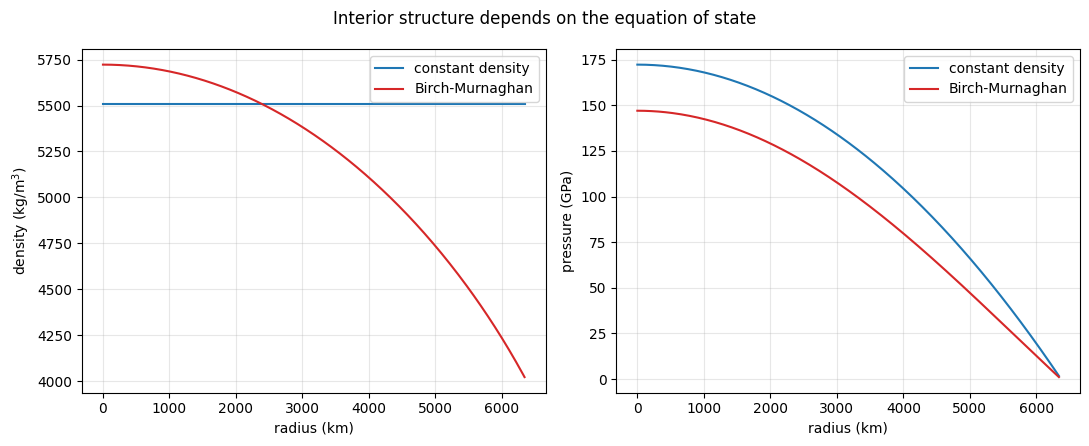

central pressure (constant density): 172.3 GPa
central pressure (Birch-Murnaghan) : 147.0 GPa


In [2]:
const_world = build_terrestrial(lambda: ConstantDensityEOS(reference_density=5510.0))
bm_world = build_terrestrial(lambda: BirchMurnaghanEOS(
    reference_density=4000.0, reference_bulk_modulus=200.0e9, bulk_modulus_derivative=4.0))

radii = np.linspace(1.0, 0.995 * 6.371e6, 300)
radii_km = radii / 1.0e3

fig, (ax_rho, ax_p) = plt.subplots(1, 2, figsize=(11, 4.5))
for world, label, color in [(const_world, "constant density", "tab:blue"),
                            (bm_world, "Birch-Murnaghan", "tab:red")]:
    ax_rho.plot(radii_km, world.get_density(radii), color=color, label=label)
    ax_p.plot(radii_km, world.get_pressure(radii) / 1.0e9, color=color, label=label)
ax_rho.set_ylabel("density (kg/m$^3$)")
ax_p.set_ylabel("pressure (GPa)")
for ax in (ax_rho, ax_p):
    ax.set_xlabel("radius (km)"); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Interior structure depends on the equation of state")
fig.tight_layout()
plt.show()

print(f"central pressure (constant density): {const_world.central_pressure/1e9:.1f} GPa")
print(f"central pressure (Birch-Murnaghan) : {bm_world.central_pressure/1e9:.1f} GPa")


## Warming the Mantle Through Partial Melt

With a partial-melt model attached, raising the interior temperature toward the liquidus reduces the effective shear modulus as melt accumulates, and a softer mantle deforms more under the tide. The sweep below takes the uniform mantle temperature across the melting range and reads the post-melt shear modulus at mid-depth.

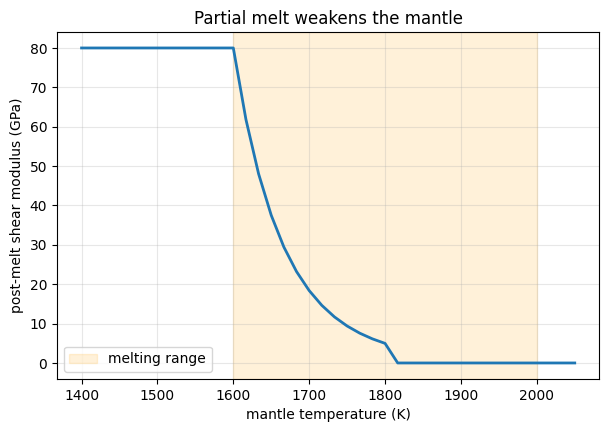

shear modulus at 1400 K: 80.0 GPa
shear modulus at 2050 K: 0.0 GPa


In [3]:
melt_model = lambda: make_partial_melt("henning", {"solidus_k": 1600.0, "liquidus_k": 2000.0})
temperatures = np.linspace(1400.0, 2050.0, 40)
mid_radius = 0.5 * 6.371e6

shear = []
for T in temperatures:
    w = build_terrestrial(lambda: ConstantDensityEOS(reference_density=5510.0),
                          temperature=T, partial_melt=melt_model)
    shear.append(w.get_shear_modulus(mid_radius))
shear = np.array(shear)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(temperatures, shear / 1.0e9, lw=2)
ax.axvspan(1600.0, 2000.0, color="orange", alpha=0.15, label="melting range")
ax.set_xlabel("mantle temperature (K)")
ax.set_ylabel("post-melt shear modulus (GPa)")
ax.set_title("Partial melt weakens the mantle")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print(f"shear modulus at {temperatures[0]:.0f} K: {shear[0]/1e9:.1f} GPa")
print(f"shear modulus at {temperatures[-1]:.0f} K: {shear[-1]/1e9:.1f} GPa")


## Recap

- Each layer's equation of state sets its pressure-density structure. A compressible EOS such as Birch-Murnaghan grades density with depth, climbing toward the center, where a constant-density layer stays uniform.
- The two example worlds share a radius but not a mass, so the lighter Birch-Murnaghan world ends up with the lower central pressure. `BirchMurnaghanEOS`, `VinetEOS`, `ConstantDensityEOS`, and `InterpolatedEOS` are all available, and `solve_eos` integrates whichever you attach.
- Temperature enters through partial melting: warming the mantle toward its liquidus softens it, which in turn strengthens the tidal response built in the earlier notebooks.

The `Systems` notebooks assemble these pieces into multi-world systems and evolve them in time. Notebook `13_tidal_maps_3d` returns to the three-dimensional tidal response of notebook 9.
